# Homework 1: NAIP Imagery
## Tatar Anurakwongsri
## 9/22/2026

### Import libraries/packages

In [1]:
# --- standard library ---------------------------------------------------
import os, os.path
import glob
import urllib.request                      # downloads a URL to a local file

# --- searching and signing the Planetary Computer catalog ---------------
import pystac_client                       # STAC API client: search for imagery
import planetary_computer as pc            # signs Microsoft's asset URLs

# --- raster and vector I/O ----------------------------------------------
import rasterio as rio                     # read/write GeoTIFFs
import fiona                               # read/write vector files (shapefiles)
import geopandas as gpd                    # vector data as a table (used for a quick map)

# --- geometry and arrays -------------------------------------------------
import numpy as np
from shapely.geometry import shape, box, mapping, Polygon   # build/convert geometries

# --- plotting -------------------------------------------------------------
from matplotlib import pyplot as plt

# --- NDVI calculation -------------------------------------------------------------
from rasterio.plot import show
from rasterio.mask import mask
from rasterio.windows import get_data_window
from rasterio.windows import Window
from rasterio.merge import merge
# optional - turn off warnings
import warnings
warnings.filterwarnings('ignore')

## 1. Define Portland, ME boundary

In [4]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=pc.sign_inplace,
)

In [71]:
# fiona opens a vector file as a stream of features. Using `with` closes it for us.
shpfile = 'data/portland/portland-boundary_4326.shp'

with fiona.open(shpfile) as lyr:
    print("CRS of the input file:", lyr.crs.to_string())   # must be EPSG:4326
    print("Number of features   :", len(lyr))

    # Convert every feature to a shapely geometry. Keeping them in a list (rather
    # than merging them) means this works for a boundary made of several polygons.
    city_parts = [shape(feat['geometry']) for feat in lyr]

    # .bounds gives the extent of the whole layer: (minx, miny, maxx, maxy)
    left, bottom, right, top = lyr.bounds

print("\nBounding box (lon/lat):", (left, bottom, right, top))

# shapely's box() builds the rectangle; mapping() converts it to the GeoJSON dict
# that the STAC API expects.
area_of_interest = mapping(box(left, bottom, right, top))
area_of_interest

CRS of the input file: EPSG:4326
Number of features   : 1

Bounding box (lon/lat): (-70.34739931383315, 43.5443388222194, -69.97585060571247, 43.727687590560805)


{'type': 'Polygon',
 'coordinates': (((-69.97585060571247, 43.5443388222194),
   (-69.97585060571247, 43.727687590560805),
   (-70.34739931383315, 43.727687590560805),
   (-70.34739931383315, 43.5443388222194),
   (-69.97585060571247, 43.5443388222194)),)}

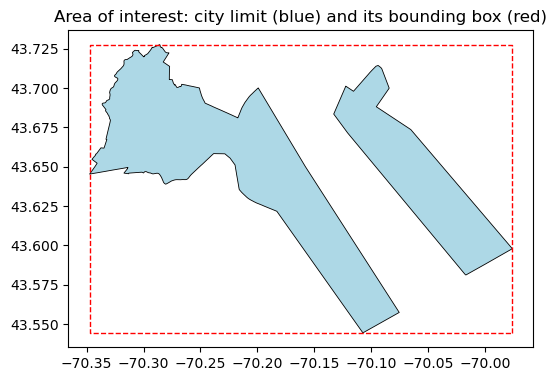

In [6]:
# Sanity check: draw the city outline inside its bounding box.
# Always look at your AOI before firing off an 8 GB download.
fig, ax = plt.subplots(figsize=(6, 6))

gpd.read_file(shpfile).plot(ax=ax, color="lightblue", edgecolor="black", linewidth=0.6)
gpd.GeoSeries([box(left, bottom, right, top)], crs="EPSG:4326").boundary.plot(
    ax=ax, color="red", linestyle="--", linewidth=1
)

ax.set_title("Area of interest: city limit (blue) and its bounding box (red)")
plt.show()

### Specify Year of NAIP Images

In [7]:
startDate = '2021-01-01'
endDate   = '2022-12-31'
range_time = f"{startDate}/{endDate}"     # STAC wants a single "START/END" string

search = catalog.search(
    collections=["naip"],          # which dataset
    intersects=area_of_interest,   # where  (GeoJSON geometry, EPSG:4326)
    datetime=range_time,           # when
)

# .item_collection() actually sends the request and pages through all the results.
# (Older tutorials call .get_items() -- that name is deprecated.)
items_tiles = search.item_collection()

print(f"{len(items_tiles)} NAIP tiles found for {range_time}")

18 NAIP tiles found for 2021-01-01/2022-12-31


### Inspect Before Downloading

In [8]:
# Look at a single Item to see what the catalog knows about it
item = items_tiles[0]

print("id       :", item.id)
print("date     :", item.datetime.date())
print("state    :", item.properties.get("naip:state"))
print("gsd      :", item.properties.get("gsd"), "m per pixel")
print("assets   :", list(item.assets))
print("\nimage href (signed, truncated):")
print(item.assets["image"].href[:120], "...")

id       : me_m_4307031_sw_19_060_20211007
date     : 2021-10-07
state    : me
gsd      : 0.6 m per pixel
assets   : ['image', 'thumbnail', 'tilejson', 'rendered_preview']

image href (signed, truncated):
https://naipeuwest.blob.core.windows.net/naip/v002/me/2021/me_060cm_2021/43070/m_4307031_sw_19_060_20211007.tif?st=2026- ...


## 2. Download NAIP Files

In [9]:
def naip_downloader(shpfile, outfolder, startDate, endDate,
                    skip_existing=True, max_tiles=None):
    """
    Download every NAIP tile that overlaps a study area, for a given date range.

    Tiles are saved unmodified, in NAIP's native band order:
        band 1 = Red, band 2 = Green, band 3 = Blue, band 4 = Near-Infrared

    Parameters
    ----------
    shpfile : str
        Path to a polygon shapefile of the study area. Must be in EPSG:4326.
    outfolder : str
        Folder to write the GeoTIFFs into. Created if it does not exist.
    startDate, endDate : str
        Date range to search, as 'YYYY-MM-DD' (e.g. '2017-06-01', '2017-09-30').
    skip_existing : bool
        If True, do not re-download tiles that are already in `outfolder`.
    max_tiles : int or None
        Stop after this many tiles. Useful for testing; None means download all.

    Returns
    -------
    list of str
        Paths of the tiles that now exist locally for this study area.
    """
    os.makedirs(outfolder, exist_ok=True)

    # --- 1. Read the study area, and build a bounding box for the search ---
    with fiona.open(shpfile) as lyr:
        if lyr.crs.to_string() != 'EPSG:4326':
            raise ValueError(
                f"{shpfile} is in {lyr.crs.to_string()}; STAC needs EPSG:4326. "
                "Reproject it first: gpd.read_file(f).to_crs('EPSG:4326')"
            )
        city_parts = [shape(feat['geometry']) for feat in lyr]
        left, bottom, right, top = lyr.bounds

    area_of_interest = mapping(box(left, bottom, right, top))

    # --- 2. Search the catalog -------------------------------------------
    catalog = pystac_client.Client.open(
        "https://planetarycomputer.microsoft.com/api/stac/v1",
        modifier=pc.sign_inplace,      # sign every asset URL for us
    )
    items_tiles = catalog.search(
        collections=["naip"],
        intersects=area_of_interest,
        datetime=f"{startDate}/{endDate}",
    ).item_collection()

    print(f"{len(items_tiles)} tiles found for {startDate}/{endDate}")

    # --- 3. Keep only the tiles that really touch the study area ----------
    # item.geometry is the tile footprint in EPSG:4326, the same CRS as the study
    # area, so we can compare them directly -- and we do it BEFORE downloading.
    keep = [it for it in items_tiles
            if any(shape(it.geometry).intersects(part) for part in city_parts)]
    print(f"{len(keep)} of them actually intersect the study area "
          f"({len(items_tiles) - len(keep)} bounding-box-only tiles skipped)")

    if max_tiles:
        keep = keep[:max_tiles]

    # --- 4. Download ------------------------------------------------------
    downloaded = []
    for n, item in enumerate(keep, start=1):
        outfilename = os.path.join(outfolder, item.id + ".tif")

        if skip_existing and os.path.exists(outfilename):
            print(f"[{n}/{len(keep)}] {item.id} -- already on disk")
            downloaded.append(outfilename)
            continue

        print(f"[{n}/{len(keep)}] downloading {item.id} ...")
        urllib.request.urlretrieve(item.assets["image"].href, outfilename)
        downloaded.append(outfilename)

    print(f"\n{len(downloaded)} tiles available in '{outfolder}'")
    return downloaded

### Call Function to Download NAIP Files

In [46]:
shapefile  = 'data/portland/portland-boundary_4326.shp'   # study area, must be EPSG:4326
cir_naips  = 'data/cir-naip'                   # where the tiles go
startDate = '2021-01-01'
endDate = '2022-12-31'

tiles = naip_downloader(shapefile, cir_naips, startDate, endDate)

18 tiles found for 2021-01-01/2022-12-31
11 of them actually intersect the study area (7 bounding-box-only tiles skipped)
[1/11] me_m_4307031_nw_19_060_20211007 -- already on disk
[2/11] me_m_4307023_sw_19_060_20211007 -- already on disk
[3/11] me_m_4307023_se_19_060_20211007 -- already on disk
[4/11] me_m_4307023_nw_19_060_20211007 -- already on disk
[5/11] me_m_4307023_ne_19_060_20211007 -- already on disk
[6/11] me_m_4307024_sw_19_060_20211006 -- already on disk
[7/11] me_m_4307024_nw_19_060_20211006 -- already on disk
[8/11] me_m_4307022_sw_19_060_20210722 -- already on disk
[9/11] me_m_4307022_se_19_060_20210722 -- already on disk
[10/11] me_m_4307022_nw_19_060_20210722 -- already on disk
[11/11] downloading me_m_4307022_ne_19_060_20210722 ...

11 tiles available in 'data/cir-naip'


## 3. View Tile and Mask Out Out-of-Bound Pixel

In [51]:
# Pick whatever tile is on disk rather than hard-coding a filename, so this cell
# works no matter which study area you downloaded.
tiffile = sorted(glob.glob(os.path.join('data/cir-naip', '*.tif')))[0]
print("Opening:", tiffile)

dataset = rio.open(tiffile)

print("CRS        :", dataset.crs)
print("Size       :", dataset.width, "x", dataset.height, "pixels")
print("Bands      :", dataset.count, dataset.dtypes)
print("Resolution :", dataset.res, "(metres per pixel)")
print("Bounds     :", dataset.bounds)
print("File size  :", os.path.getsize(tiffile) / 1e6, "MB")

Opening: data/cir-naip\me_m_4307022_ne_19_060_20210722.tif
CRS        : EPSG:26919
Size       : 9501 x 12605 pixels
Bands      : 4 ('uint8', 'uint8', 'uint8', 'uint8')
Resolution : (0.6, 0.6) (metres per pixel)
Bounds     : BoundingBox(left=393961.8, bottom=4837679.4, right=399662.39999999997, top=4845242.4)
File size  : 425.554679 MB


### Read at Reduced Resolution

In [52]:
dsfactor = 10                              # read 1 pixel in every 10
h = dataset.height // dsfactor
w = dataset.width  // dsfactor
print(f"Resampling {dataset.width}x{dataset.height} -> {w}x{h} for display")

# rasterio band indices start at 1
red   = dataset.read(1, out_shape=(h, w))
green = dataset.read(2, out_shape=(h, w))
blue  = dataset.read(3, out_shape=(h, w))
nir   = dataset.read(4, out_shape=(h, w))

for name, band in [("red", red), ("green", green), ("blue", blue), ("NIR", nir)]:
    print(f"{name:>5}: min={band.min():3d}  max={band.max():3d}  mean={band.mean():6.1f}")

Resampling 9501x12605 -> 950x1260 for display
  red: min=  7  max=255  mean=  83.7
green: min= 19  max=255  mean=  90.2
 blue: min= 41  max=255  mean=  84.5
  NIR: min=  0  max=251  mean= 126.1


### View Natural Color vs Colour-Infrared vs Near-Infrared

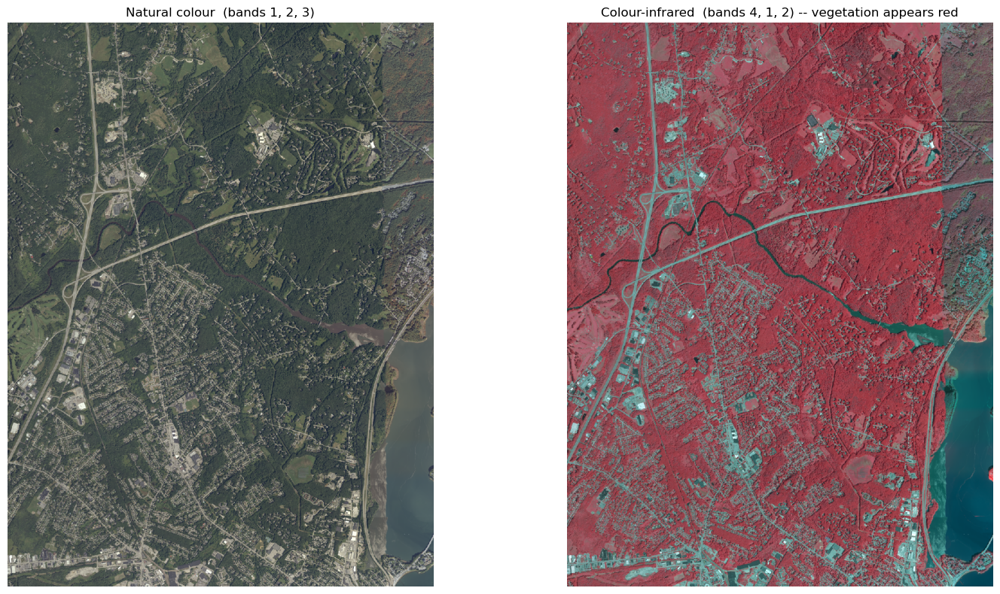

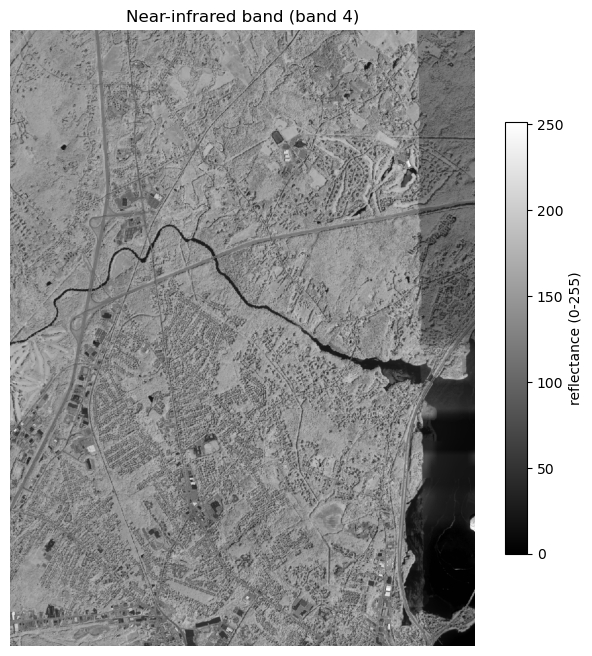

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Natural colour: R, G, B -> screen R, G, B
natural = np.dstack((red, green, blue))
axes[0].imshow(natural)
axes[0].set_title("Natural colour  (bands 1, 2, 3)")

# Colour-infrared: NIR, R, G -> screen R, G, B
cir = np.dstack((nir, red, green))
axes[1].imshow(cir)
axes[1].set_title("Colour-infrared  (bands 4, 1, 2) -- vegetation appears red")

for ax in axes:
    ax.set_axis_off()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(nir, cmap='gray')
ax.set_title("Near-infrared band (band 4)")
ax.set_axis_off()
plt.colorbar(im, ax=ax, shrink=0.7, label="reflectance (0-255)")
plt.show()

dataset.close() 

## 4. Calculate the NDVI and Vegetation Cover Map

### Read Raster Data and Get Metadata

In [55]:
naip_file = 'data/cir-naip/me_m_4307022_ne_19_060_20210722.tif'
naip_dataset = rio.open(naip_file)
naip_bounds = naip_dataset.bounds
naip_dataset.meta

{'driver': 'GTiff',
 'dtype': 'uint8',
 'nodata': None,
 'width': 9501,
 'height': 12605,
 'count': 4,
 'crs': CRS.from_wkt('PROJCS["NAD83 / UTM zone 19N",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-69],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","26919"]]'),
 'transform': Affine(0.6, 0.0, 393961.8,
        0.0, -0.6, 4845242.4)}

Text(0.5, 1.0, 'Visualization of Portland, ME NAIP File')

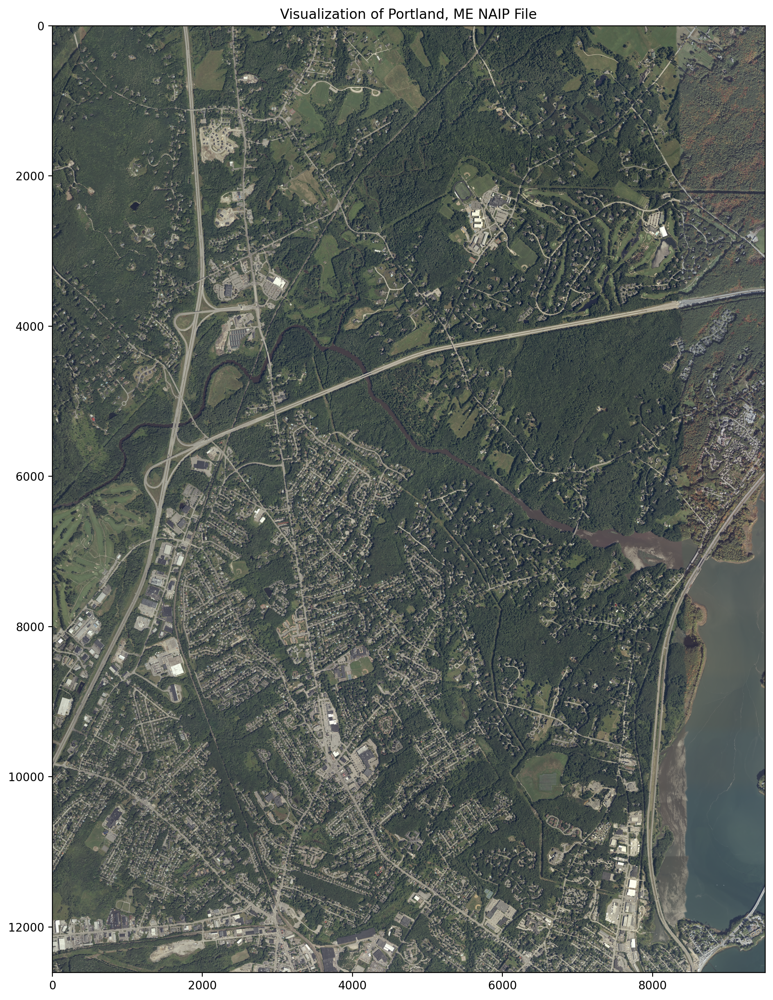

In [56]:
naip_dataset = rio.open(naip_file)

# read the different bands of the raster data
nir = np.float32(naip_dataset.read(4))
blue = np.float32(naip_dataset.read(3))
green = np.float32(naip_dataset.read(2))
red = np.float32(naip_dataset.read(1))


# stack different layer images
cir = np.dstack((red,green,blue))


# plt.imshow(band1)
plt.figure(figsize=(15, 15), dpi=200)
plt.imshow(cir.astype(np.uint8))
plt.title("Visualization of Portland, ME NAIP File")

### Display NAIP Images

Resampling to 6302,4750


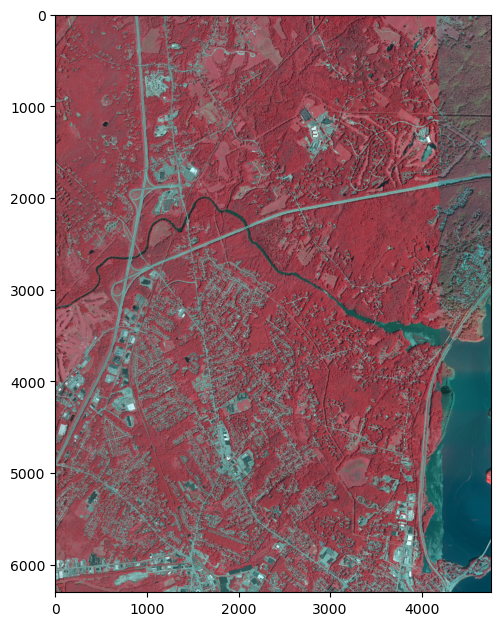

In [57]:
def display_naip_tile(filename, dsfactor = 2):
    """
    Display a NAIP tile using rasterio.
    
    dsfactor: downsample factor
    For .mrf-formatted tiles (which span multiple files), 'filename' should refer to the 
    .mrf file.
    """
    
    # NAIP tiles are enormous; downsize for plotting in this notebook
    
    with rio.open(filename) as raster:
        # rasterio uses 1-based indexing for channels.
        h = int(raster.height/dsfactor)
        w = int(raster.width/dsfactor)
        print('Resampling to {},{}'.format(h,w))
        ir = raster.read(4, out_shape=(1, h, w))
        r = raster.read(1, out_shape=(1, h, w))
        g = raster.read(2, out_shape=(1, h, w))
        
    cir = np.dstack((ir,r,g))
    fig = plt.figure(figsize=(7.5, 7.5), dpi=100, edgecolor='k')
    plt.imshow(cir)
    raster.close()
    
display_naip_tile(naip_file)

### Calculate NDVI from NAIP Image

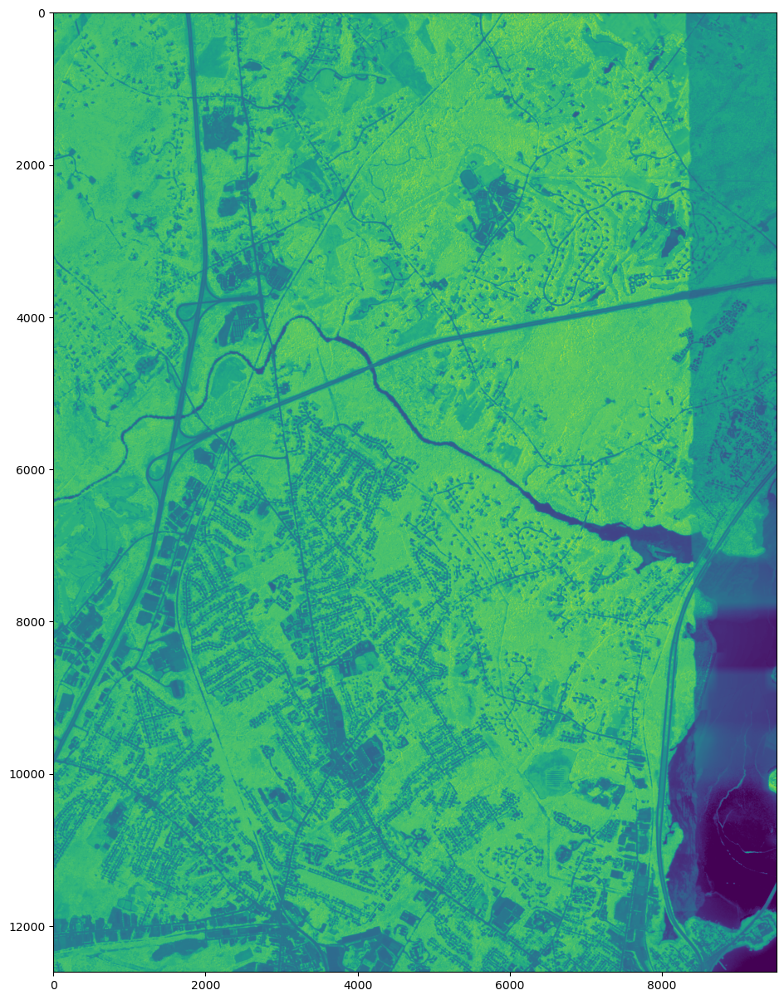

In [58]:
ndvi = (nir - red)/(nir + red + 0.000001)

plt.figure(figsize=(15, 15))
plt.imshow(ndvi)

### Extract Vegetation from NDVI

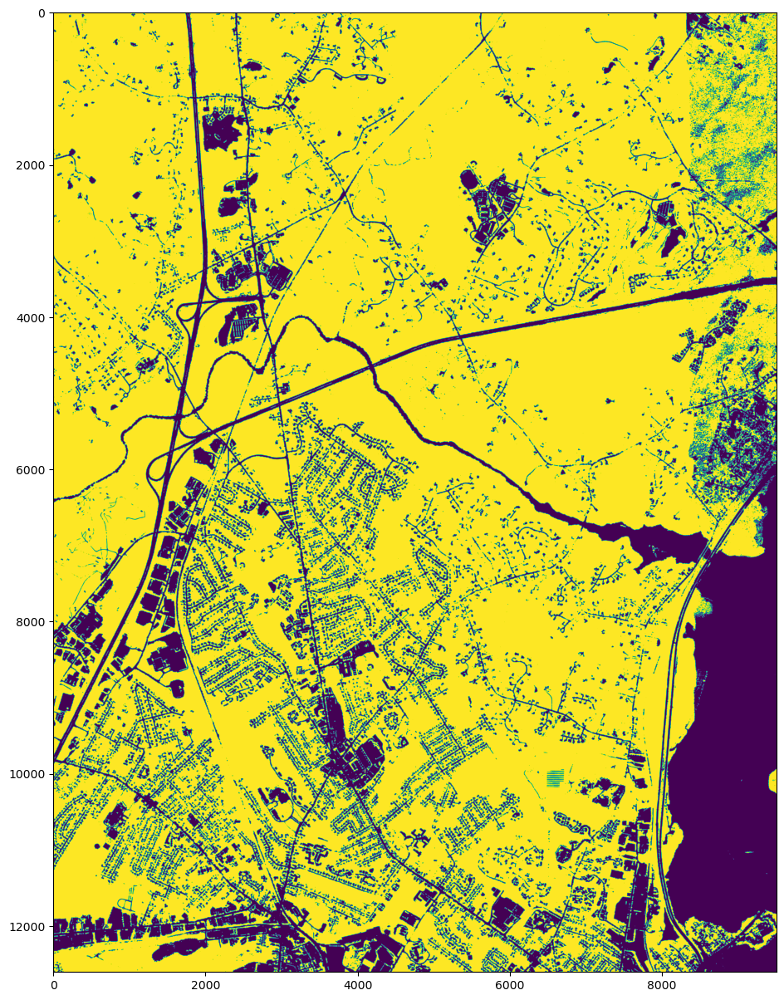

In [59]:
plt.figure(figsize=(15, 15))

veg = np.zeros((ndvi.shape[0], ndvi.shape[1]), dtype = np.uint8)
veg[ndvi > 0] = 1

plt.imshow(veg)

### Save Vegetation Raster Data as New .tif File

In [60]:
out_tif = 'data/veg.tif'

# prepare the schema of the new tiles
out_meta = naip_dataset.meta.copy()

# update the schema of the NDVI image, because it is different from the raw NAIP image, like only one band
out_meta.update({'count': 1,
                 'compress': 'lzw'}
               )

out_meta

{'driver': 'GTiff',
 'dtype': 'uint8',
 'nodata': None,
 'width': 9501,
 'height': 12605,
 'count': 1,
 'crs': CRS.from_wkt('PROJCS["NAD83 / UTM zone 19N",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-69],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","26919"]]'),
 'transform': Affine(0.6, 0.0, 393961.8,
        0.0, -0.6, 4845242.4),
 'compress': 'lzw'}

In [61]:
veg.shape

(12605, 9501)

In [63]:
# update the schema of the ndvi image, because it is different from teh raw naip image, like only one band
out_meta.update({'count': 1,
                 'compress': 'lzw'}
               )

# this is required, because rio will use three dimension, even this is single band image
veg = veg.reshape(1, veg.shape[0], veg.shape[1])

ValueError: cannot reshape array of size 119760105 into shape (1,1,12605)

In [64]:
veg.shape

(1, 12605, 9501)

In [65]:
with rio.open(out_tif, "w", **out_meta) as dest:
    dest.write(veg)

## 5. Generate Census Tract Level Map of NDVI and Vegetation Cover

### Mosaic Tiles into One 

In [72]:
# This function is used to mosaic geotiffs in the input folder
# Parameters:
#     dirpath: the folder name of the tif files
#     outfile: the output file of the mosaiced geotiff image

inputfolder= 'data/cir-naip'
outfile = 'data/mosaiced-naip.tif'

# start to mosaic the raster tiles
tiflist = []

for file in os.listdir(inputfolder):    
    if file.endswith('.tif'):
        tiffile = os.path.join(inputfolder, file)
        tiflist.append(tiffile)

src_files_to_mosaic = []
for fp in tiflist:
    try:
        tile_src = rio.open(fp)
        tile_bounds = tile_src.bounds
        
        src_files_to_mosaic.append(tile_src)
    except:
        continue

print('The number of mosaiced tiles is:', len(src_files_to_mosaic))

# the method can be set as min, max..
mosaic, out_trans = merge(src_files_to_mosaic) #, method='max'
print('You have mosaiced the results')


# Prepare the schema of the output mosacied image
out_meta = tile_src.meta.copy()
out_meta.update({"driver": "GTiff",
                  "height": mosaic.shape[1],
                  "width": mosaic.shape[2],
                  "transform": out_trans, 
                  "compress": 'lzw',
                  'BIGTIFF': 'YES'
                  }
               )

#out_fp = os.path.join(dirpath, 'atlanta-naip.tif')
with rio.open(outfile, "w", **out_meta) as dest:
     dest.write(mosaic)

The number of mosaiced tiles is: 11
You have mosaiced the results


In [10]:
out_meta

{'driver': 'GTiff',
 'dtype': 'uint16',
 'nodata': None,
 'width': 2000,
 'height': 2000,
 'count': 1,
 'crs': CRS.from_wkt('PROJCS["NAD83 / UTM zone 19N",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-69],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","26919"]]'),
 'transform': Affine(0.6, 0.0, 402131.39999999997,
        0.0, -0.6, 4831632.0),
 'compress': 'lzw'}

### Mask Mosaic Raster

In [2]:
input_value_raster = 'data/mosaiced-naip.tif'
shpfile = 'data/portland/portland-boundary_26919.shp'
out_raster = 'data/maskPortland-naip.tif'

with fiona.open(shpfile, "r") as shapefile:
    shapes = [feature["geometry"] for feature in shapefile]

with rio.open(input_value_raster) as src:
    out_image, out_transform = mask(src, shapes, crop=True)
    out_meta = src.meta

out_meta.update({"driver": "GTiff",
                 "height": out_image.shape[1],
                 "width": out_image.shape[2],
                 "compress": 'lzw',
                 "transform": out_transform})

with rio.open(out_raster, "w", **out_meta) as dest:
    dest.write(out_image)   

### Clip Large Raster Data into Smaller Files

In [4]:
lu_dataset = rio.open('data/maskPortland-naip.tif')
outfolder = 'data/naip-tiles'
if not os.path.exists(outfolder):
    os.mkdir(outfolder)

lu_img = lu_dataset.read()

# height and width of the raster
height, width = lu_dataset.shape

# split the large raster into number of tiles, tile size is 2000*2000
tile_width = 2000
tile_height = 2000

tile_num_col = int(width/tile_width) + 1
tile_num_row = int(height/tile_height) + 1

# the output folder
if not os.path.exists(outfolder): os.mkdir(outfolder)

# create each tile
for i in range(tile_num_row - 1):
    # loop each column
    for j in range(tile_num_col - 1):
        tilename = os.path.join(outfolder, 'row%s-col%s.tif'%(i, j))
        
        row_start = i*tile_height
        col_start = j*tile_width
        row_end = (i + 1)*tile_height
        col_end = (j + 1)*tile_width
        
        # deal with the right boundary
        if row_end > height - 1: tile_height = height - row_start
        if col_end > width - 1: tile_width = width - col_start
        
        # window = get_data_window(lu_dataset.read(1, masked=True))
        window = Window(col_off=col_start, row_off=row_start, width=tile_width, height=tile_height)
        
        kwargs = lu_dataset.meta.copy()
        kwargs.update({
            'height': window.height,
            'width': window.width,
            'transform': rio.windows.transform(window, lu_dataset.transform)})
        
        with rio.open(tilename, 'w', **kwargs) as dst:
            dst.write(lu_dataset.read(window=window))

### Loop All Split Tiles and Compute Vegetation Cover

In [5]:
out_tif = 'data/veg.tif'
infolder = 'data/naip-tiles'
outfolder = 'data/veg-tiles'

if not os.path.exists(outfolder):
    os.mkdir(outfolder)

for file in os.listdir(infolder):
    tiffile = os.path.join(infolder, file)
    
    # read the different bands of the raster data
    if not tiffile.endswith('.tif'): continue
    naip_dataset = rio.open(tiffile)
    green = np.float32(naip_dataset.read(3))
    red = np.float32(naip_dataset.read(2))
    nir = np.float32(naip_dataset.read(1))

    # here add 0.0000001 is to make sure the nir+red is not zero
    ndvi = (nir - red)/(nir + red + 0.000001)
    
    # extract the vegetation based on the ndvi
    veg = np.zeros((ndvi.shape[0], ndvi.shape[1]), dtype = np.uint16)
    veg[ndvi > 0] = 1
    
    
    # prepare the schema of the new tiles
    out_meta = naip_dataset.meta.copy()

    # update the schema of the ndvi image, because it is different from teh raw naip image, like only one band
    out_meta.update({'count': 1,
                    'dtype': 'uint16',
                     "height": ndvi.shape[0],
                     "width": ndvi.shape[1],
    #                  "transform": out_transform,
                     "crs": naip_dataset.crs, 
                     'compress': 'lzw'}
                   )
    
    
    # this is required, because rio will use three dimension, even this is single band image
    veg = veg.reshape(1, veg.shape[0], veg.shape[1])
    
    out_tif = os.path.join(outfolder, file)
    with rio.open(out_tif, "w", **out_meta) as dest:
        dest.write(veg)
    

### Overlay Shapefile on Raster Data

In [11]:
inraster = 'data/maskPortland-naip.tif'
input_zone_polygon = 'data/portland/maine-census-tract_26919.shp'
output_shp_res = 'data/vegCoverCensus-tract.shp'

# Open the raster datasets
naip_dataset = rio.open(inraster)

# Prepare the polygon shapefile and then do the overlay of the raster data and the vector data
lyr = fiona.open(input_zone_polygon)
schema = lyr.schema
schema['properties']['ndvi'] = 'float'


with fiona.open(output_shp_res, 'w', driver = "ESRI Shapefile", crs = lyr.crs, schema=schema) as output:
    for idx, feat in enumerate(lyr):
        props = feat['properties']
        geom = feat['geometry']
        shape = [geom] # the rasterio need the list, therefore, create a list

        try:
        
            # mask the raster using the polygon
            outNAIP_image, out_transform = rio.mask.mask(naip_dataset, shape, 
                                                              nodata = 0,
                                                              crop=True)
            
            # calculate the ndvi from the clipped naip img, convert the int to float using numpy
            nir = np.float32(outNAIP_image[0, :, :])
            red = np.float32(outNAIP_image[1, :, :])
            ndvi = (nir - red)/(nir + red + 0.000001)
            
            # calculate the ndvi value
            mean_val = np.sum(ndvi)/np.count_nonzero(ndvi)
            
            # update the calculated ndvi value to the field
            props['ndvi'] = mean_val
            output.write({'properties': props,
                          'geometry': geom
                         })
        
        except ValueError:
            # If the polygon does not overlap the raster, ignore the error and move to the next one
            print(f"Skipped index {idx}: No overlap with raster")
            continue

Skipped index 0: No overlap with raster
Skipped index 1: No overlap with raster
Skipped index 2: No overlap with raster
Skipped index 3: No overlap with raster
Skipped index 4: No overlap with raster
Skipped index 5: No overlap with raster
Skipped index 6: No overlap with raster
Skipped index 7: No overlap with raster
Skipped index 8: No overlap with raster
Skipped index 9: No overlap with raster
Skipped index 10: No overlap with raster
Skipped index 11: No overlap with raster
Skipped index 12: No overlap with raster
Skipped index 13: No overlap with raster
Skipped index 14: No overlap with raster
Skipped index 15: No overlap with raster
Skipped index 16: No overlap with raster
Skipped index 17: No overlap with raster
Skipped index 18: No overlap with raster
Skipped index 19: No overlap with raster
Skipped index 20: No overlap with raster
Skipped index 21: No overlap with raster
Skipped index 22: No overlap with raster
Skipped index 23: No overlap with raster
Skipped index 24: No overl

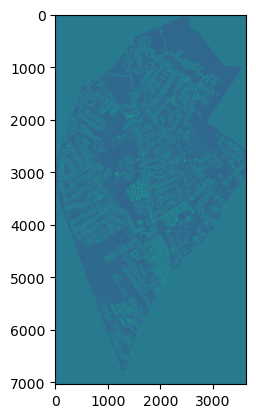

In [13]:
plt.imshow(nir - red)

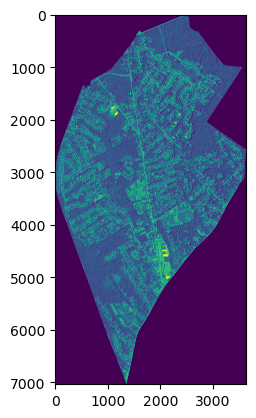

In [14]:
plt.imshow(outNAIP_image[0,:,:])

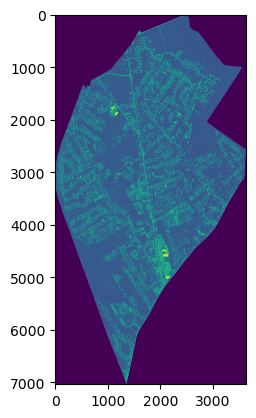

In [15]:
plt.imshow(outNAIP_image[2,:,:])

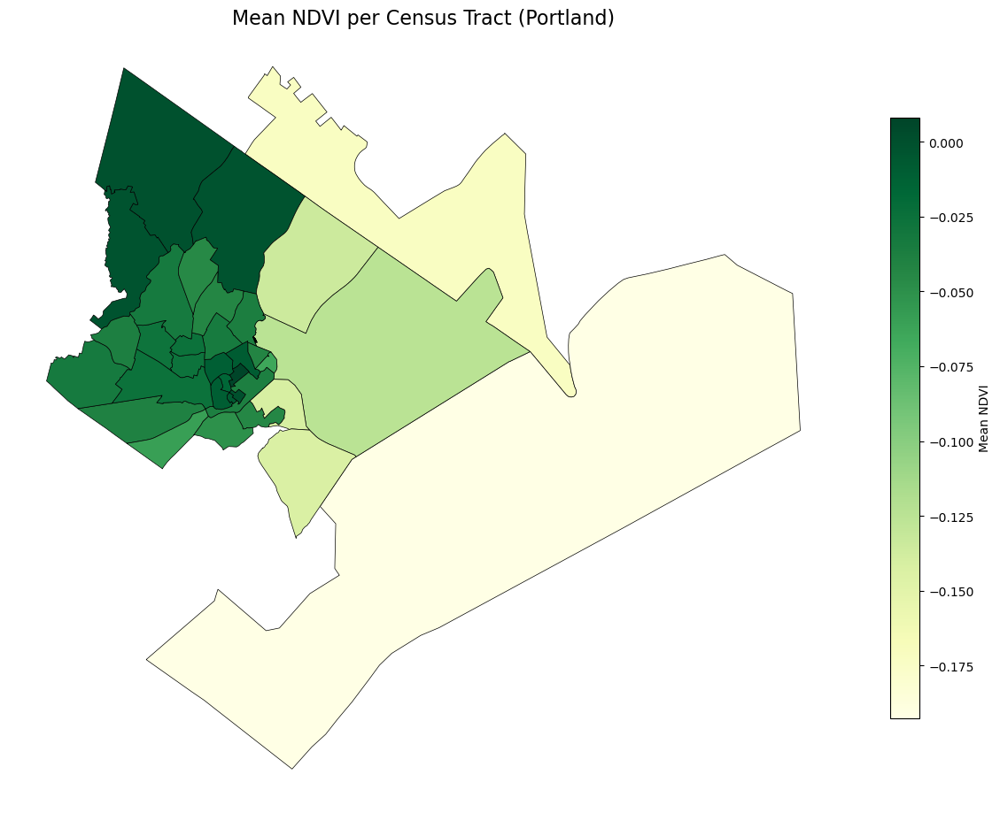

In [2]:
output_shp_res = 'data/vegCoverCensus-tract.shp'
tracts_with_ndvi = gpd.read_file(output_shp_res)

# Set up the figure size
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot the shapefile, coloring it by the 'ndvi' column
# 'YlGn' (Yellow-Green) is a standard colormap for vegetation
tracts_with_ndvi.plot(column='ndvi', 
                      ax=ax, 
                      cmap='YlGn', 
                      edgecolor='black', 
                      linewidth=0.5,
                      legend=True,
                      legend_kwds={'label': "Mean NDVI", 
                                   'orientation': "vertical",
                                   'shrink': 0.7})

# Clean up the visual appearance
ax.set_title("Mean NDVI per Census Tract (Portland)", fontsize=16)
ax.set_axis_off()

plt.tight_layout()
plt.show()